## Decoding image identity from VISp with CEBRA

This notebook adapts the official CEBRA Allen workflow (for figure 3b) to the Allen Visual Behavior Neuropixels dataset.  
We use CEBRA to try to answer: **Can CEBRA learn a low-dimensional latent representation of VISp spiking activity that accurately predicts which (static) image was presented?**

### Setup

We use the Allen Visual Behavior Neuropixels dataset.  
Here are the imports we used. They are similar to those used in our replication step. We then build the neural matrix ourselves from repeated image presentations.

In [6]:
import os
import random
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import PCA
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, balanced_accuracy_score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

from allensdk.brain_observatory.behavior.behavior_project_cache.behavior_neuropixels_project_cache import (
    VisualBehaviorNeuropixelsProjectCache,
)
from cebra import CEBRA

seed = 0
random.seed(seed)
np.random.seed(seed)

cache_dir = "./allen_vbn_cache"
os.makedirs(cache_dir, exist_ok=True)

cache = VisualBehaviorNeuropixelsProjectCache.from_s3_cache(cache_dir=cache_dir)
print("Cache ready:", cache_dir)

Cache ready: ./allen_vbn_cache


In [7]:
import torch
print("CUDA:", torch.cuda.is_available())
print("MPS:", torch.backends.mps.is_available())

CUDA: True
MPS: False


### Preapring the data

We restruct the Allen Visual Behavior Neuropixels data to strictly VISp (primary visual cortex) data. We choose a single session based on how many VISp data is contained within each one. Our candidate sessions IDs are taken from a manual data inspection.

In [8]:
sessions = cache.get_ecephys_session_table()
units = cache.get_unit_table()

print("Number of sessions:", len(sessions))
print("Number of units:", len(units))

Number of sessions: 103
Number of units: 319013


In [9]:
candidate_sessions = [1108334384, 1087723305, 1043752325]

visp_counts = (
    units.loc[units["structure_acronym"] == "VISp"]
    .groupby("ecephys_session_id")
    .size()
    .rename("n_visp_units")
)

candidate_summary = pd.DataFrame(index=candidate_sessions)
candidate_summary["n_visp_units"] = visp_counts.reindex(candidate_sessions).fillna(0).astype(int)

display(candidate_summary)

session_id = candidate_summary["n_visp_units"].idxmax()
print("Selected session:", session_id)

session = cache.get_ecephys_session(ecephys_session_id=session_id)

,n_visp_units
1108334384,220
1087723305,189
1043752325,231


Selected session: 1043752325


c:\Users\nikoz\Desktop\cebrasd\.venv\Lib\site-packages\hdmf\spec\namespace.py:772: UserWarning: Ignoring the following cached namespace(s) because another version is already loaded:
core - cached version: 2.6.0-alpha, loaded version: 2.7.0
The loaded extension(s) may not be compatible with the cached extension(s) in the file. Please check the extension documentation and ignore this warning if these versions are compatible.
  self.warn_for_ignored_namespaces(ignored_namespaces)


### Inspect the stimulus templates

The original visual CEBRA workflow is tied to what appears on the screen. In this adapted notebook, the closest analogue is the set of flashed image templates used in the static-image task.

,warped
image_name,
im036_r,"[[70, 71, 67, 63, 64, 69, 73, 73, 71, 70, 73, ..."
im012_r,"[[25, 27, 21, 14, 15, 23, 29, 28, 22, 18, 20, ..."
im044_r,"[[20, 23, 16, 9, 9, 18, 24, 23, 16, 12, 14, 20..."
im047_r,"[[63, 65, 62, 58, 58, 63, 67, 67, 65, 64, 65, ..."
im083_r,"[[6, 9, 2, 0, 0, 0, 7, 5, 0, 0, 0, 2, 7, 6, 2,..."


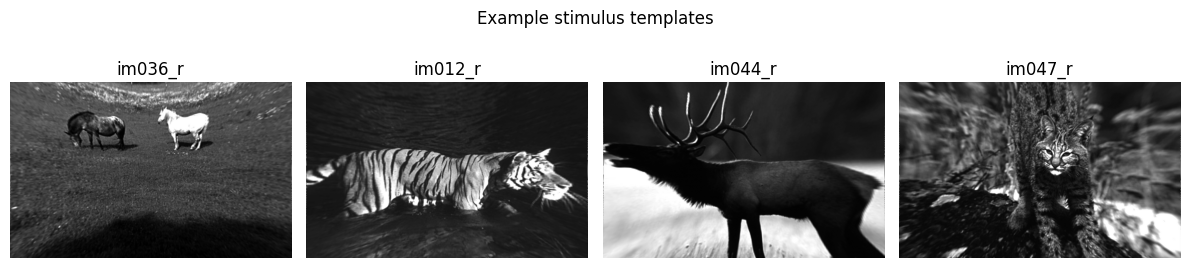

In [10]:
templates = session.stimulus_templates.copy()

display(templates.drop(columns=["unwarped"], errors="ignore").head())

if "warped" in templates.columns:
    image_names = templates.index[:4]
    fig, axes = plt.subplots(1, len(image_names), figsize=(12, 3))

    for ax, img_name in zip(axes, image_names):
        ax.imshow(templates.loc[img_name, "warped"], cmap="gray")
        ax.set_title(str(img_name))
        ax.axis("off")

    plt.suptitle("Example stimulus templates")
    plt.tight_layout()
    plt.show()

### Build a repeated-image dataset

To stay close to the demo’s visual-content decoding setup, we use repeated image presentations.
We keep non-omitted image flashes and, when available, prefer passive/non-change presentations to reduce motor and decision-related contamination.

In [11]:
stim = session.stimulus_presentations.copy()

stim = stim.dropna(subset=["image_name", "start_time"]).copy()

if "omitted" in stim.columns:
    stim = stim[~stim["omitted"]].copy()

if "is_change" in stim.columns:
    stim = stim[~stim["is_change"]].copy()

stim = stim[stim["image_name"].astype(str).str.startswith("im")].copy()

top_images = stim["image_name"].value_counts().index[:8]
stim = stim[stim["image_name"].isin(top_images)].copy()

min_count = stim["image_name"].value_counts().min()
stim_balanced = (
    stim.groupby("image_name", group_keys=False)
    .sample(n=min_count, random_state=seed)
    .sort_values("start_time")
    .reset_index(drop=True)
)

print("Balanced presentations per image:", min_count)
print("Total balanced presentations:", len(stim_balanced))
display(stim_balanced["image_name"].value_counts().sort_index())
display(stim_balanced.head())

Balanced presentations per image: 798
Total balanced presentations: 6384


im012_r    798
im036_r    798
im044_r    798
im047_r    798
im078_r    798
im083_r    798
im111_r    798
im115_r    798
Name: image_name, dtype: int64

,stimulus_block,image_name,duration,start_time,end_time,start_frame,end_frame,is_change,is_image_novel,omitted,...,orientation,stimulus_name,rewarded,position_x,is_sham_change,temporal_frequency,color,active,contrast,spatial_frequency
0,0,im036_r,0.250211,26.274263,26.524474,60,75,False,False,False,...,NaN,Natural_Images_Lum_Matched_set_ophys_G_2019,False,NaN,False,NaN,NaN,True,NaN,NaN
1,0,im036_r,0.250211,27.024897,27.275108,105,120,False,False,False,...,NaN,Natural_Images_Lum_Matched_set_ophys_G_2019,False,NaN,False,NaN,NaN,True,NaN,NaN
2,0,im036_r,0.250209,27.775526,28.025734,150,165,False,False,False,...,NaN,Natural_Images_Lum_Matched_set_ophys_G_2019,False,NaN,False,NaN,NaN,True,NaN,NaN
3,0,im036_r,0.250216,28.526159,28.776376,195,210,False,False,False,...,NaN,Natural_Images_Lum_Matched_set_ophys_G_2019,False,NaN,False,NaN,NaN,True,NaN,NaN
4,0,im036_r,0.266881,29.276808,29.543689,240,256,False,False,False,...,NaN,Natural_Images_Lum_Matched_set_ophys_G_2019,False,NaN,False,NaN,NaN,True,NaN,NaN


### Select VISp units and construct presentation-aligned neural responses

Each image presentation will be represented as a short post-stimulus firing-rate response across VISp neurons and time bins.

In [12]:
session_units = units[units["ecephys_session_id"] == session_id].copy()

if "quality" in session_units.columns:
    visp_units = session_units[
        (session_units["structure_acronym"] == "VISp") &
        (session_units["quality"] == "good")
    ].copy()
else:
    visp_units = session_units[
        session_units["structure_acronym"] == "VISp"
    ].copy()

summary_table = pd.DataFrame({
    "n_visp_units": [len(visp_units)]
})

unit_id_table = pd.DataFrame({
    "unit_id": visp_units.index
})

display(summary_table)
display(unit_id_table.head())

,n_visp_units
0,194


,unit_id
0,1163291401
1,1163291395
2,1163291577
3,1163291440
4,1163291667


In [13]:
bin_size = 0.025
window_start = 0.0
window_end = 0.25

bins = np.arange(window_start, window_end + bin_size, bin_size)
bin_centers = bins[:-1] + bin_size / 2

spike_times = session.spike_times
unit_ids = visp_units.index.to_numpy()

presentation_times = stim_balanced["start_time"].to_numpy()
presentation_labels = stim_balanced["image_name"].to_numpy()

n_presentations = len(presentation_times)
n_units = len(unit_ids)
n_bins = len(bin_centers)

print(f"Window: {window_start:.3f}s to {window_end:.3f}s")
print(f"Bin size: {bin_size:.3f}s")
print(f"Building tensor: {n_presentations} presentations x {n_units} units x {n_bins} bins")

firing_rates = np.zeros((n_presentations, n_units, n_bins), dtype=np.float32)

for i, t0 in enumerate(presentation_times):
    for j, uid in enumerate(unit_ids):
        spikes = spike_times[uid]
        rel_spikes = spikes - t0
        counts, _ = np.histogram(rel_spikes, bins=bins)
        firing_rates[i, j, :] = counts.astype(np.float32) / bin_size

print("firing_rates shape:", firing_rates.shape)

Window: 0.000s to 0.250s
Bin size: 0.025s
Building tensor: 6384 presentations x 194 units x 10 bins
firing_rates shape: (6384, 194, 10)


### Visualize the raw dataset before modeling

Now that the presentation × neuron × time-bin tensor has been constructed, we can inspect the balanced image set and the average VISp responses before fitting any model.

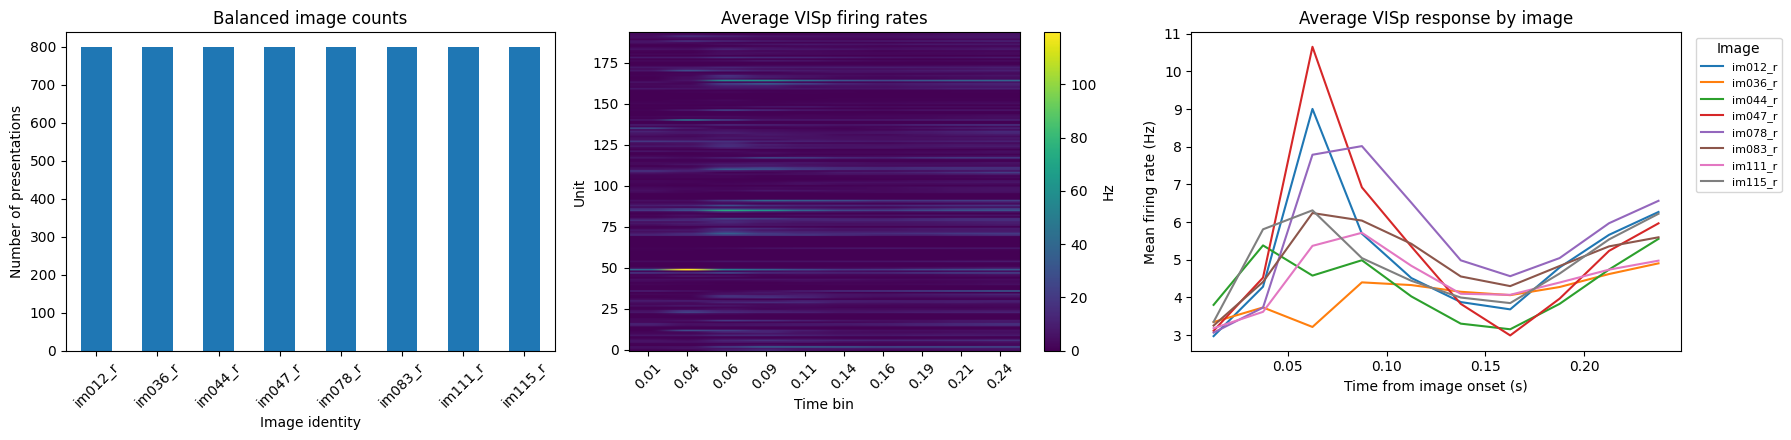

In [14]:
image_counts = stim_balanced["image_name"].value_counts().sort_index()
population_mean = firing_rates.mean(axis=0)

mean_by_image = {}
for img in sorted(stim_balanced["image_name"].unique()):
    mean_by_image[img] = firing_rates[presentation_labels == img].mean(axis=(0, 1))

fig, axes = plt.subplots(1, 3, figsize=(18, 4.5))

image_counts.plot(kind="bar", ax=axes[0])
axes[0].set_title("Balanced image counts")
axes[0].set_xlabel("Image identity")
axes[0].set_ylabel("Number of presentations")
axes[0].tick_params(axis="x", rotation=45)

im = axes[1].imshow(population_mean, aspect="auto", origin="lower")
axes[1].set_title("Average VISp firing rates")
axes[1].set_xlabel("Time bin")
axes[1].set_ylabel("Unit")
axes[1].set_xticks(range(len(bin_centers)))
axes[1].set_xticklabels([f"{t:.2f}" for t in bin_centers], rotation=45)
fig.colorbar(im, ax=axes[1], label="Hz")

for img, trace in mean_by_image.items():
    axes[2].plot(bin_centers, trace, label=img)

axes[2].set_title("Average VISp response by image")
axes[2].set_xlabel("Time from image onset (s)")
axes[2].set_ylabel("Mean firing rate (Hz)")
axes[2].legend(title="Image", bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=8)

plt.tight_layout()
plt.show()

### Prepare labels and define helper functions

To train and evaluate the models, we encode image labels, flatten the tensor into bin-level samples, average bin-level embeddings back to the presentation level, and choose k for cosine-distance kNN.

In [15]:
label_encoder = LabelEncoder()
y_all = label_encoder.fit_transform(presentation_labels)
class_names = label_encoder.classes_

def make_bin_level_dataset(x_3d, y_1d, bin_centers):
    n_presentations, n_units, n_bins = x_3d.shape
    x_bins = np.transpose(x_3d, (0, 2, 1)).reshape(n_presentations * n_bins, n_units)
    y_bins = np.repeat(y_1d, n_bins)
    time_bins = np.tile(bin_centers, n_presentations)
    return x_bins, y_bins, time_bins

def average_bins_back_to_presentations(z_bins, n_presentations, n_bins):
    return z_bins.reshape(n_presentations, n_bins, -1).mean(axis=1)

def choose_best_k(x_train, y_train, x_val, y_val, k_values=None):
    if k_values is None:
        k_values = [1, 3, 5, 7, 9, 11, 15]

    best_k = None
    best_score = -np.inf

    for k in k_values:
        clf = KNeighborsClassifier(n_neighbors=k, metric="cosine")
        clf.fit(x_train, y_train)
        y_pred = clf.predict(x_val)
        score = balanced_accuracy_score(y_val, y_pred)

        if score > best_score:
            best_score = score
            best_k = k

    return best_k, best_score

### Split the dataset into train, validation, and test sets

We use a stratified presentation-level split, then derive both presentation-level mean features and bin-level features from the same data.

In [16]:
indices = np.arange(len(y_all))

train_val_idx, test_idx = train_test_split(
    indices,
    test_size=0.20,
    stratify=y_all,
    random_state=seed,
)

train_idx, val_idx = train_test_split(
    train_val_idx,
    test_size=0.25,
    stratify=y_all[train_val_idx],
    random_state=seed,
)

x_train = firing_rates[train_idx]
x_val = firing_rates[val_idx]
x_test = firing_rates[test_idx]

y_train = y_all[train_idx]
y_val = y_all[val_idx]
y_test = y_all[test_idx]

print("Train presentations:", len(train_idx))
print("Validation presentations:", len(val_idx))
print("Test presentations:", len(test_idx))

x_train_mean = x_train.mean(axis=2)
x_val_mean = x_val.mean(axis=2)
x_test_mean = x_test.mean(axis=2)

scaler_mean = StandardScaler()
x_train_mean_z = scaler_mean.fit_transform(x_train_mean)
x_val_mean_z = scaler_mean.transform(x_val_mean)
x_test_mean_z = scaler_mean.transform(x_test_mean)

x_train_bins, y_train_bins, train_time_bins = make_bin_level_dataset(x_train, y_train, bin_centers)
x_val_bins, y_val_bins, val_time_bins = make_bin_level_dataset(x_val, y_val, bin_centers)
x_test_bins, y_test_bins, test_time_bins = make_bin_level_dataset(x_test, y_test, bin_centers)

scaler_bins = StandardScaler()
x_train_bins_z = scaler_bins.fit_transform(x_train_bins)
x_val_bins_z = scaler_bins.transform(x_val_bins)
x_test_bins_z = scaler_bins.transform(x_test_bins)

print("x_train_bins_z shape:", x_train_bins_z.shape)
print("x_val_bins_z shape:", x_val_bins_z.shape)
print("x_test_bins_z shape:", x_test_bins_z.shape)

Train presentations: 3830
Validation presentations: 1277
Test presentations: 1277
x_train_bins_z shape: (38300, 194)
x_val_bins_z shape: (12770, 194)
x_test_bins_z shape: (12770, 194)


### Baseline decoders

Before fitting CEBRA, we compare several simpler methods:

- chance accuracy,
- raw mean firing rates + kNN,
- raw mean firing rates + Gaussian Naive Bayes,
- raw mean firing rates + logistic regression,
- PCA features + kNN.

In [17]:
baseline_rows = []
baseline_predictions = {}

chance_accuracy = 1 / len(class_names)
baseline_rows.append({
    "model": f"Chance ({len(class_names)} classes)",
    "accuracy": chance_accuracy
})

best_k_raw, _ = choose_best_k(x_train_mean_z, y_train, x_val_mean_z, y_val)
raw_knn = KNeighborsClassifier(n_neighbors=best_k_raw, metric="cosine")
raw_knn.fit(x_train_mean_z, y_train)
y_pred_raw_knn = raw_knn.predict(x_test_mean_z)
acc_raw_knn = accuracy_score(y_test, y_pred_raw_knn)

baseline_rows.append({
    "model": "Raw mean + kNN",
    "accuracy": acc_raw_knn
})
baseline_predictions["Raw mean + kNN"] = y_pred_raw_knn

gnb = GaussianNB()
gnb.fit(x_train_mean, y_train)
y_pred_gnb = gnb.predict(x_test_mean)
acc_gnb = accuracy_score(y_test, y_pred_gnb)

baseline_rows.append({
    "model": "Raw mean + GaussianNB",
    "accuracy": acc_gnb
})
baseline_predictions["Raw mean + GaussianNB"] = y_pred_gnb

logreg = LogisticRegression(max_iter=5000, random_state=seed)
logreg.fit(x_train_mean_z, y_train)
y_pred_logreg = logreg.predict(x_test_mean_z)
acc_logreg = accuracy_score(y_test, y_pred_logreg)

baseline_rows.append({
    "model": "Raw mean + LogisticRegression",
    "accuracy": acc_logreg
})
baseline_predictions["Raw mean + LogisticRegression"] = y_pred_logreg

pca = PCA(n_components=8, random_state=seed)
x_train_pca = pca.fit_transform(x_train_mean_z)
x_val_pca = pca.transform(x_val_mean_z)
x_test_pca = pca.transform(x_test_mean_z)

best_k_pca, _ = choose_best_k(x_train_pca, y_train, x_val_pca, y_val)
pca_knn = KNeighborsClassifier(n_neighbors=best_k_pca, metric="cosine")
pca_knn.fit(x_train_pca, y_train)
y_pred_pca = pca_knn.predict(x_test_pca)
acc_pca = accuracy_score(y_test, y_pred_pca)

baseline_rows.append({
    "model": "PCA + kNN",
    "accuracy": acc_pca
})
baseline_predictions["PCA + kNN"] = y_pred_pca

baseline_df = pd.DataFrame(baseline_rows).sort_values("accuracy", ascending=False)
display(baseline_df)

,model,accuracy
3,Raw mean + LogisticRegression,0.996085
1,Raw mean + kNN,0.935004
4,PCA + kNN,0.910728
2,Raw mean + GaussianNB,0.786218
0,Chance (8 classes),0.125000


In [18]:
baseline_rows = []
baseline_predictions = {}

chance_accuracy = 1 / len(class_names)
baseline_rows.append({
    "model": f"Chance ({len(class_names)} classes)",
    "accuracy": chance_accuracy
})

best_k_raw, _ = choose_best_k(x_train_mean_z, y_train, x_val_mean_z, y_val)
raw_knn = KNeighborsClassifier(n_neighbors=best_k_raw, metric="cosine")
raw_knn.fit(x_train_mean_z, y_train)
y_pred_raw_knn = raw_knn.predict(x_test_mean_z)
acc_raw_knn = accuracy_score(y_test, y_pred_raw_knn)

baseline_rows.append({
    "model": "Raw mean + kNN",
    "accuracy": acc_raw_knn
})
baseline_predictions["Raw mean + kNN"] = y_pred_raw_knn

gnb = GaussianNB()
gnb.fit(x_train_mean, y_train)
y_pred_gnb = gnb.predict(x_test_mean)
acc_gnb = accuracy_score(y_test, y_pred_gnb)

baseline_rows.append({
    "model": "Raw mean + GaussianNB",
    "accuracy": acc_gnb
})
baseline_predictions["Raw mean + GaussianNB"] = y_pred_gnb

logreg = LogisticRegression(max_iter=5000, random_state=seed)
logreg.fit(x_train_mean_z, y_train)
y_pred_logreg = logreg.predict(x_test_mean_z)
acc_logreg = accuracy_score(y_test, y_pred_logreg)

baseline_rows.append({
    "model": "Raw mean + LogisticRegression",
    "accuracy": acc_logreg
})
baseline_predictions["Raw mean + LogisticRegression"] = y_pred_logreg

pca = PCA(n_components=8, random_state=seed)
x_train_pca = pca.fit_transform(x_train_mean_z)
x_val_pca = pca.transform(x_val_mean_z)
x_test_pca = pca.transform(x_test_mean_z)

best_k_pca, _ = choose_best_k(x_train_pca, y_train, x_val_pca, y_val)
pca_knn = KNeighborsClassifier(n_neighbors=best_k_pca, metric="cosine")
pca_knn.fit(x_train_pca, y_train)
y_pred_pca = pca_knn.predict(x_test_pca)
acc_pca = accuracy_score(y_test, y_pred_pca)

baseline_rows.append({
    "model": "PCA + kNN",
    "accuracy": acc_pca
})
baseline_predictions["PCA + kNN"] = y_pred_pca

baseline_df = pd.DataFrame(baseline_rows).sort_values("accuracy", ascending=False)
display(baseline_df)

,model,accuracy
3,Raw mean + LogisticRegression,0.996085
1,Raw mean + kNN,0.935004
4,PCA + kNN,0.910728
2,Raw mean + GaussianNB,0.786218
0,Chance (8 classes),0.125000


### Train a low-dimensional CEBRA embedding for visualization

We first train an 8-dimensional CEBRA model so that the learned latent space can be visualized directly.

In [19]:
cebra_viz = CEBRA(
    model_architecture="offset10-model",
    batch_size=256,
    learning_rate=3e-4,
    temperature=1.0,
    output_dimension=8,
    max_iterations=500,
    distance="cosine",
    conditional="time_delta",
    time_offsets=3,
    device="cpu",
    verbose=True,
)

cebra_viz.fit(x_train_bins_z, train_time_bins, y_train_bins)

z_train_viz_bins = cebra_viz.transform(x_train_bins_z)
z_val_viz_bins = cebra_viz.transform(x_val_bins_z)
z_test_viz_bins = cebra_viz.transform(x_test_bins_z)

z_train_viz = average_bins_back_to_presentations(z_train_viz_bins, len(train_idx), len(bin_centers))
z_val_viz = average_bins_back_to_presentations(z_val_viz_bins, len(val_idx), len(bin_centers))
z_test_viz = average_bins_back_to_presentations(z_test_viz_bins, len(test_idx), len(bin_centers))

print("z_test_viz shape:", z_test_viz.shape)

pos: -0.8814 neg:  5.7005 total:  4.8191 temperature:  1.0000: 100%|██████████| 500/500 [00:13<00:00, 36.25it/s]


z_test_viz shape: (1277, 8)


### Train a higher-dimensional CEBRA embedding for decoding

Next, we train a larger CEBRA model intended for held-out decoding rather than visualization.

In [20]:
cebra_decode = CEBRA(
    model_architecture="offset10-model",
    batch_size=256,
    learning_rate=3e-4,
    temperature=1.0,
    output_dimension=128,
    max_iterations=500,
    distance="cosine",
    conditional="time_delta",
    time_offsets=3,
    device="cpu",
    verbose=True,
)

cebra_decode.fit(x_train_bins_z, train_time_bins, y_train_bins)

z_train_decode_bins = cebra_decode.transform(x_train_bins_z)
z_val_decode_bins = cebra_decode.transform(x_val_bins_z)
z_test_decode_bins = cebra_decode.transform(x_test_bins_z)

z_train_decode = average_bins_back_to_presentations(z_train_decode_bins, len(train_idx), len(bin_centers))
z_val_decode = average_bins_back_to_presentations(z_val_decode_bins, len(val_idx), len(bin_centers))
z_test_decode = average_bins_back_to_presentations(z_test_decode_bins, len(test_idx), len(bin_centers))

print("z_test_decode shape:", z_test_decode.shape)

pos: -0.9106 neg:  5.7056 total:  4.7951 temperature:  1.0000: 100%|██████████| 500/500 [00:13<00:00, 36.46it/s]


z_test_decode shape: (1277, 128)


### Results

Using our accuracy_score function, we check to see how good CEBRA did against the baseline

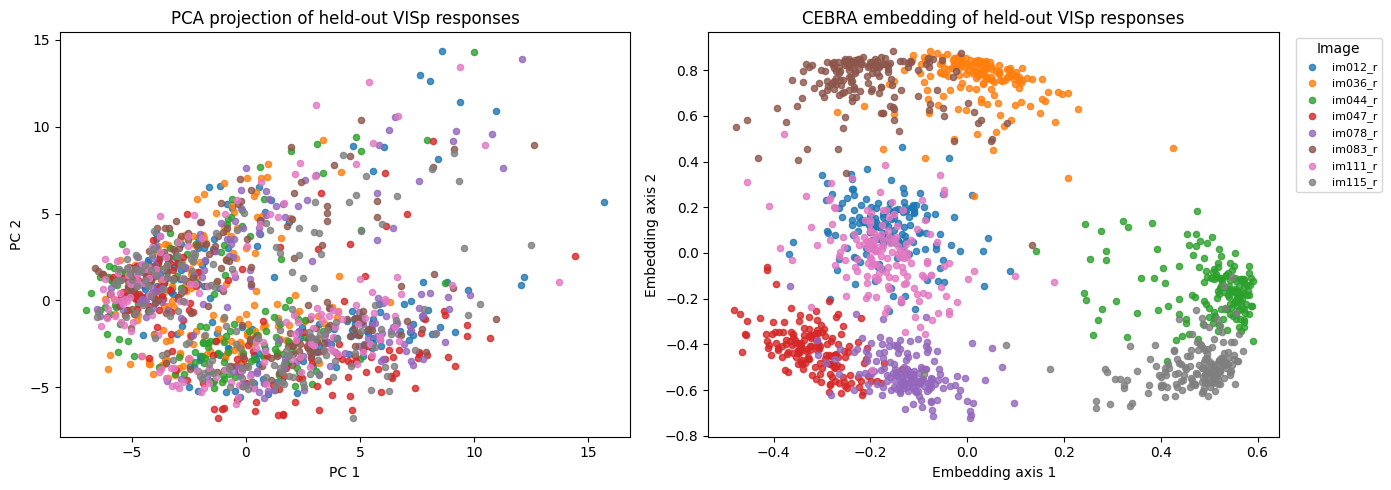

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for cls_idx, cls_name in enumerate(class_names):
    mask = y_test == cls_idx
    axes[0].scatter(
        x_test_pca[mask, 0],
        x_test_pca[mask, 1],
        s=20,
        alpha=0.8,
        label=str(cls_name),
    )

axes[0].set_title("PCA projection of held-out VISp responses")
axes[0].set_xlabel("PC 1")
axes[0].set_ylabel("PC 2")

for cls_idx, cls_name in enumerate(class_names):
    mask = y_test == cls_idx
    axes[1].scatter(
        z_test_viz[mask, 0],
        z_test_viz[mask, 1],
        s=20,
        alpha=0.8,
        label=str(cls_name),
    )

axes[1].set_title("CEBRA embedding of held-out VISp responses")
axes[1].set_xlabel("Embedding axis 1")
axes[1].set_ylabel("Embedding axis 2")
axes[1].legend(title="Image", bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=8)

plt.tight_layout()
plt.show()

In [22]:
best_k_cebra, _ = choose_best_k(z_train_decode, y_train, z_val_decode, y_val)

cebra_knn = KNeighborsClassifier(n_neighbors=best_k_cebra, metric="cosine")
cebra_knn.fit(z_train_decode, y_train)
y_pred_cebra = cebra_knn.predict(z_test_decode)

acc_cebra = accuracy_score(y_test, y_pred_cebra)

results_df = pd.DataFrame(
    baseline_rows + [{
        "model": "CEBRA-128D + kNN",
        "accuracy": acc_cebra
    }]
).sort_values("accuracy", ascending=False).reset_index(drop=True)

display(results_df)

,model,accuracy
0,Raw mean + LogisticRegression,0.996085
1,CEBRA-128D + kNN,0.953015
2,Raw mean + kNN,0.935004
3,PCA + kNN,0.910728
4,Raw mean + GaussianNB,0.786218
5,Chance (8 classes),0.125000


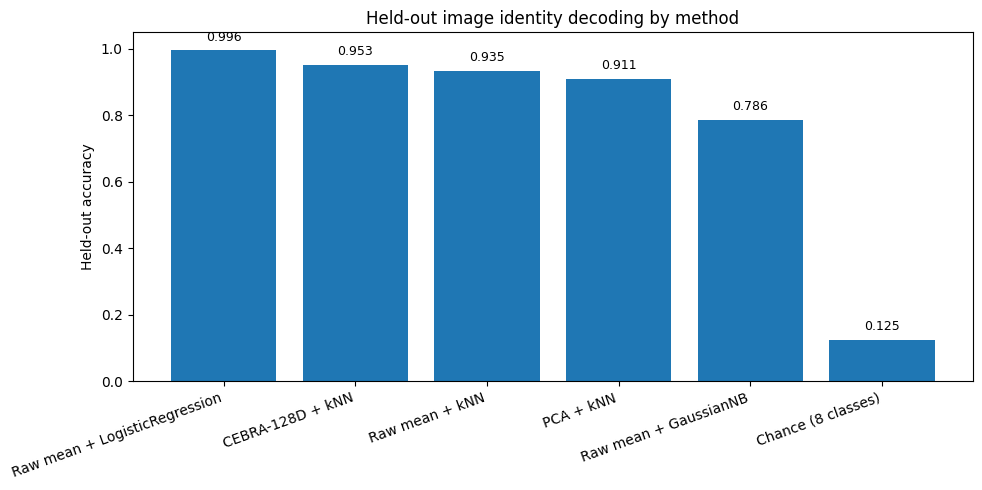

In [23]:
plot_df = results_df.copy()
x = np.arange(len(plot_df))

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(x, plot_df["accuracy"])

ax.set_xticks(x)
ax.set_xticklabels(plot_df["model"], rotation=20, ha="right")
ax.set_ylim(0, 1.05)
ax.set_ylabel("Held-out accuracy")
ax.set_title("Held-out image identity decoding by method")

for bar, value in zip(bars, plot_df["accuracy"]):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        value + 0.02,
        f"{value:.3f}",
        ha="center",
        va="bottom",
        fontsize=9
    )

plt.tight_layout()
plt.show()

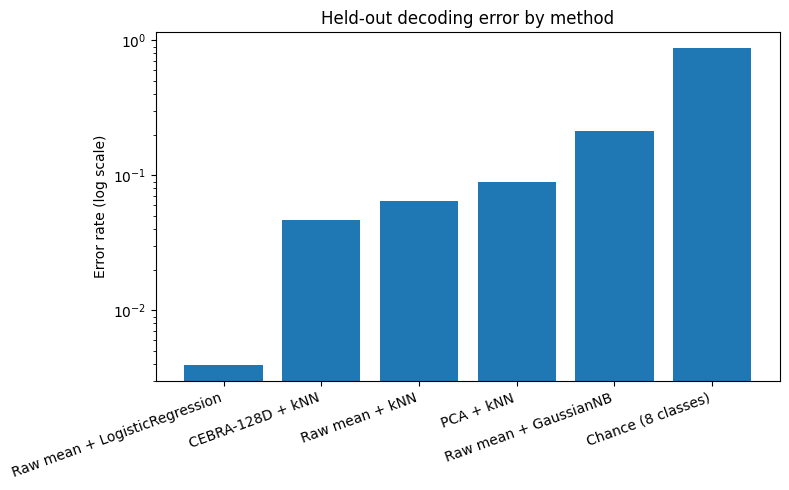

In [24]:
models = results_df["model"].tolist()
x = np.arange(len(models))

acc = results_df["accuracy"].to_numpy()
error = 1 - acc
eps = 1e-6

plt.figure(figsize=(8, 5))
plt.bar(x, error + eps)

plt.xticks(x, models, rotation=20, ha="right")
plt.yscale("log")
plt.ylabel("Error rate (log scale)")
plt.title("Held-out decoding error by method")
plt.tight_layout()
plt.show()

### Label-shuffle control

As a control, we shuffle the training image labels before fitting CEBRA. If the original labels carry meaningful structure, performance should drop after shuffling.

pos: -0.6441 neg:  5.7264 total:  5.0823 temperature:  1.0000: 100%|██████████| 300/300 [00:08<00:00, 36.22it/s]


,condition,accuracy
0,Real labels,0.953015
1,Shuffled labels,0.570086


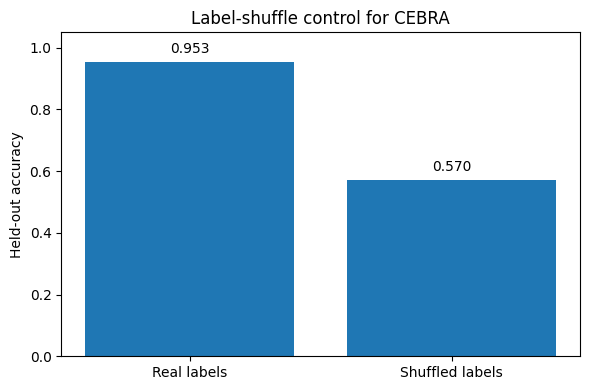

In [25]:
rng = np.random.default_rng(seed)
y_train_bins_shuffled = rng.permutation(y_train_bins)

cebra_shuffle = CEBRA(
    model_architecture="offset10-model",
    batch_size=256,
    learning_rate=3e-4,
    temperature=1.0,
    output_dimension=128,
    max_iterations=300,
    distance="cosine",
    conditional="time_delta",
    time_offsets=3,
    device="cpu",
    verbose=True,
)

cebra_shuffle.fit(x_train_bins_z, train_time_bins, y_train_bins_shuffled)

z_train_shuffle_bins = cebra_shuffle.transform(x_train_bins_z)
z_val_shuffle_bins = cebra_shuffle.transform(x_val_bins_z)
z_test_shuffle_bins = cebra_shuffle.transform(x_test_bins_z)

z_train_shuffle = average_bins_back_to_presentations(z_train_shuffle_bins, len(train_idx), len(bin_centers))
z_val_shuffle = average_bins_back_to_presentations(z_val_shuffle_bins, len(val_idx), len(bin_centers))
z_test_shuffle = average_bins_back_to_presentations(z_test_shuffle_bins, len(test_idx), len(bin_centers))

best_k_shuffle, _ = choose_best_k(z_train_shuffle, y_train, z_val_shuffle, y_val)

shuffle_knn = KNeighborsClassifier(n_neighbors=best_k_shuffle, metric="cosine")
shuffle_knn.fit(z_train_shuffle, y_train)
y_pred_shuffle = shuffle_knn.predict(z_test_shuffle)

acc_shuffle = accuracy_score(y_test, y_pred_shuffle)

control_df = pd.DataFrame({
    "condition": ["Real labels", "Shuffled labels"],
    "accuracy": [acc_cebra, acc_shuffle]
})

display(control_df)

fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(control_df["condition"], control_df["accuracy"])
ax.set_ylim(0, 1.05)
ax.set_ylabel("Held-out accuracy")
ax.set_title("Label-shuffle control for CEBRA")

for bar, value in zip(bars, control_df["accuracy"]):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        value + 0.02,
        f"{value:.3f}",
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()

### Supplementary diagnostics

The following plots provide class-by-class and geometric diagnostics of the learned representations. These are useful for interpretation, but the main result remains the held-out decoding comparison above.

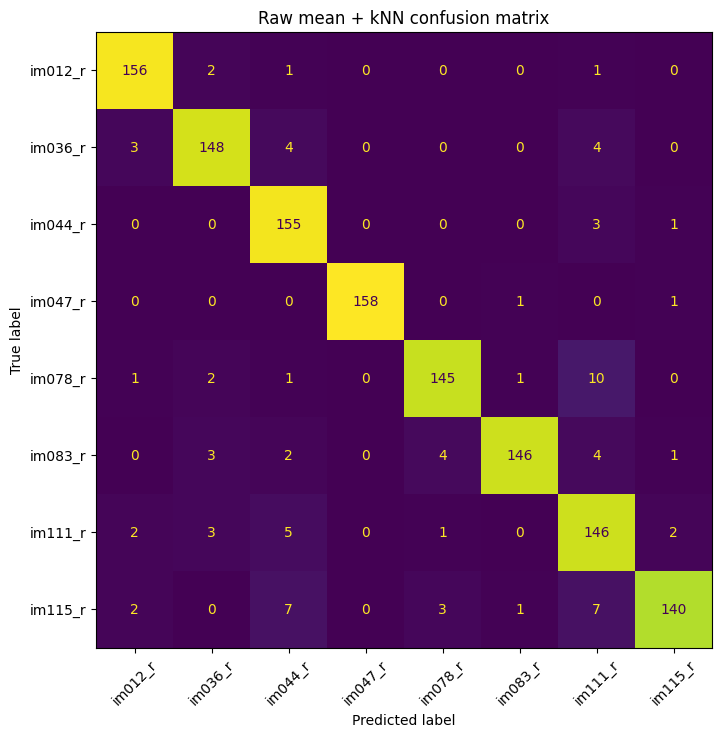

In [26]:
disp = ConfusionMatrixDisplay(
    confusion_matrix=confusion_matrix(y_test, y_pred_raw_knn),
    display_labels=class_names
)
fig, ax = plt.subplots(figsize=(8, 8))
disp.plot(ax=ax, xticks_rotation=45, colorbar=False)
plt.title("Raw mean + kNN confusion matrix")
plt.show()

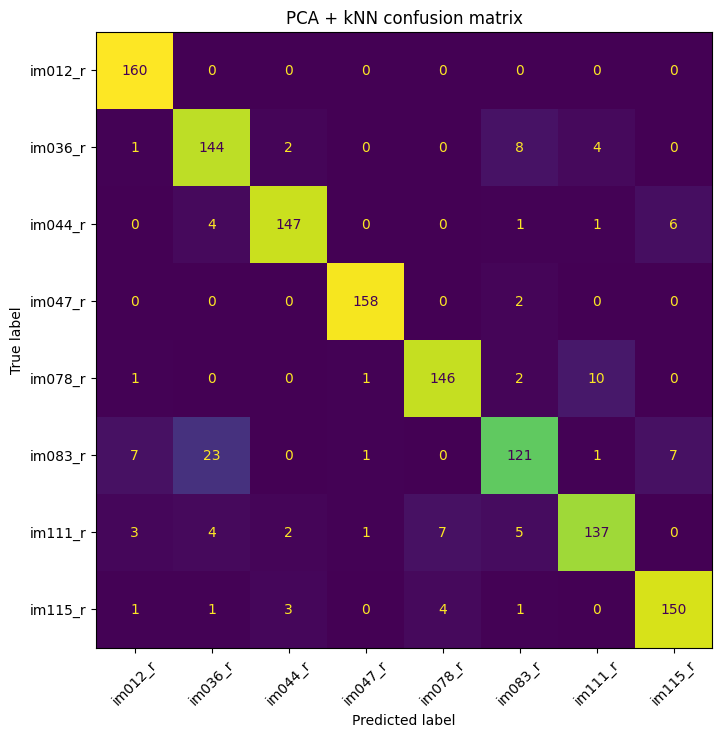

In [27]:
disp = ConfusionMatrixDisplay(
    confusion_matrix=confusion_matrix(y_test, y_pred_pca),
    display_labels=class_names
)
fig, ax = plt.subplots(figsize=(8, 8))
disp.plot(ax=ax, xticks_rotation=45, colorbar=False)
plt.title("PCA + kNN confusion matrix")
plt.show()

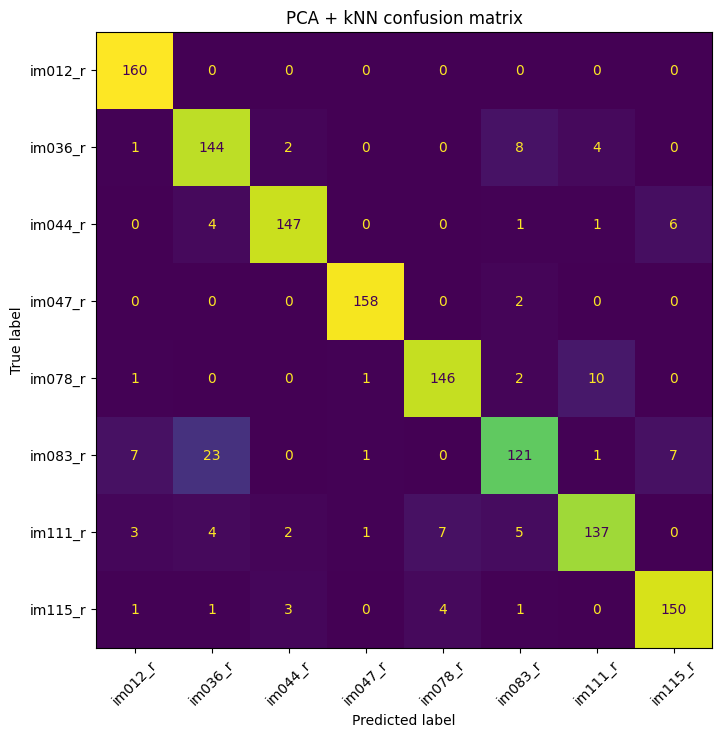

In [28]:
disp = ConfusionMatrixDisplay(
    confusion_matrix=confusion_matrix(y_test, y_pred_pca),
    display_labels=class_names
)
fig, ax = plt.subplots(figsize=(8, 8))
disp.plot(ax=ax, xticks_rotation=45, colorbar=False)
plt.title("PCA + kNN confusion matrix")
plt.show()

,model,mean_pairwise_center_distance
0,PCA,1.692142
1,CEBRA,0.775050


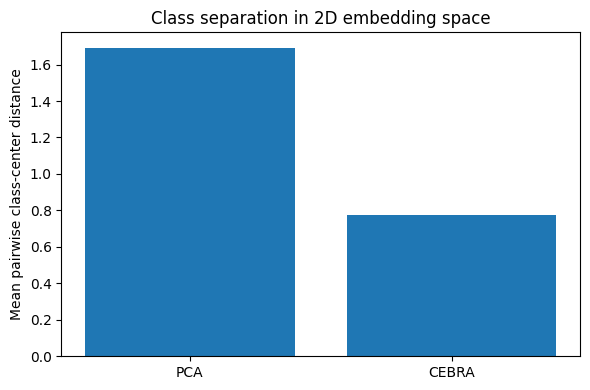

In [29]:
# error rate of each of the models. Originally did accuracy but the difference didn't seem as obvious and this type of figure gives more information
def mean_pairwise_class_distance(x, y):
    centers = []
    for cls in np.unique(y):
        centers.append(x[y == cls].mean(axis=0))
    centers = np.array(centers)

    dists = []
    for i in range(len(centers)):
        for j in range(i + 1, len(centers)):
            dists.append(np.linalg.norm(centers[i] - centers[j]))
    return np.mean(dists)

pca_sep = mean_pairwise_class_distance(x_test_pca[:, :2], y_test)
cebra_sep = mean_pairwise_class_distance(z_test_viz[:, :2], y_test)

sep_df = pd.DataFrame([
    {"model": "PCA", "mean_pairwise_center_distance": pca_sep},
    {"model": "CEBRA", "mean_pairwise_center_distance": cebra_sep},
])

display(sep_df)

plt.figure(figsize=(6, 4))
plt.bar(sep_df["model"], sep_df["mean_pairwise_center_distance"])
plt.ylabel("Mean pairwise class-center distance")
plt.title("Class separation in 2D embedding space")
plt.tight_layout()
plt.show()

,model,mean_pairwise_center_distance
0,PCA,1.692142
1,CEBRA,0.775050


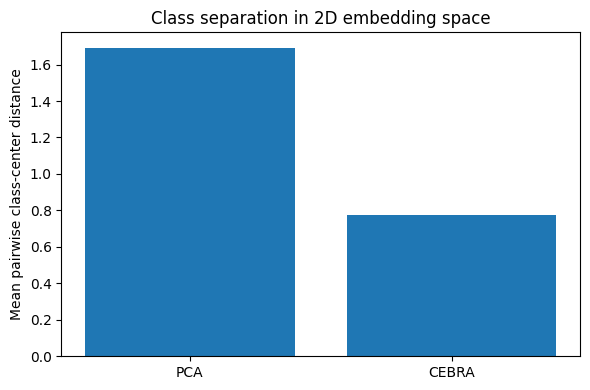

In [31]:
def mean_pairwise_class_distance(X, y):
    centers = []
    for cls in np.unique(y):
        centers.append(X[y == cls].mean(axis=0))
    centers = np.array(centers)

    dists = []
    for i in range(len(centers)):
        for j in range(i + 1, len(centers)):
            dists.append(np.linalg.norm(centers[i] - centers[j]))
    return np.mean(dists)

pca_sep = mean_pairwise_class_distance(x_test_pca[:, :2], y_test)
cebra_sep = mean_pairwise_class_distance(z_test_viz[:, :2], y_test)

sep_df = pd.DataFrame([
    {"model": "PCA", "mean_pairwise_center_distance": pca_sep},
    {"model": "CEBRA", "mean_pairwise_center_distance": cebra_sep},
])

display(sep_df)

plt.figure(figsize=(6, 4))
plt.bar(sep_df["model"], sep_df["mean_pairwise_center_distance"])
plt.ylabel("Mean pairwise class-center distance")
plt.title("Class separation in 2D embedding space")
plt.tight_layout()
plt.show()

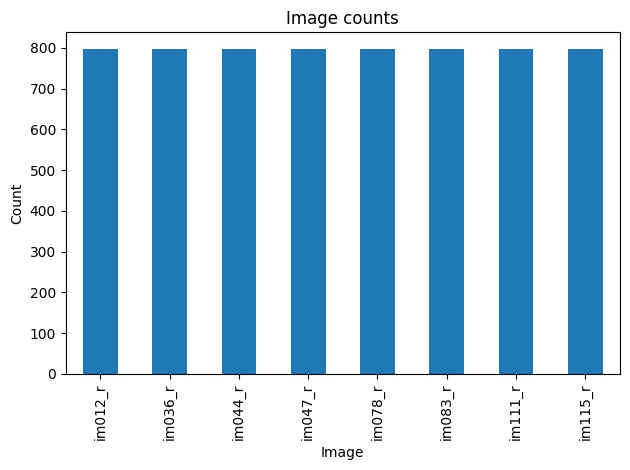

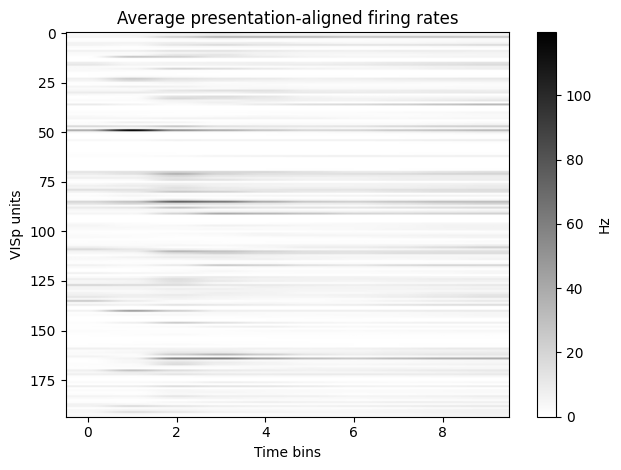

In [32]:
plt.figure()
stim_balanced["image_name"].value_counts().sort_index().plot(kind="bar")
plt.title("Image counts")
plt.xlabel("Image")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

mean_over_presentations = firing_rates.mean(axis=0)

plt.figure()
plt.imshow(mean_over_presentations, aspect="auto", cmap="gray_r")
plt.xlabel("Time bins")
plt.ylabel("VISp units")
plt.title("Average presentation-aligned firing rates")
plt.colorbar(label="Hz")
plt.tight_layout()
plt.show()

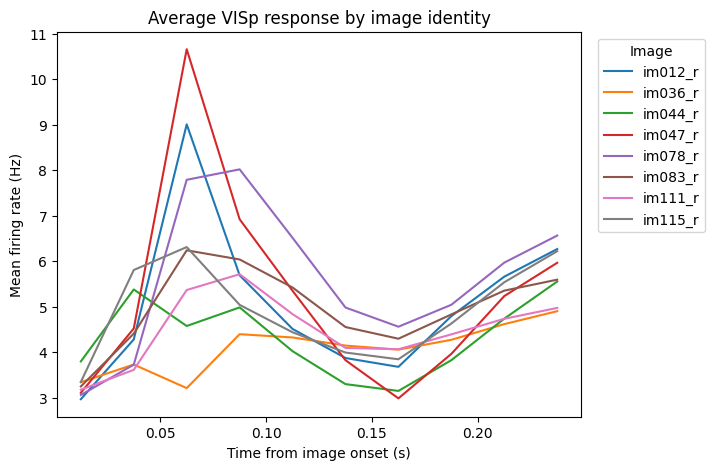

In [33]:
mean_by_image = {}
for img in sorted(stim_balanced["image_name"].unique()):
    mean_by_image[img] = firing_rates[presentation_labels == img].mean(axis=(0, 1))

fig, ax = plt.subplots(figsize=(8, 5))

for img, trace in mean_by_image.items():
    ax.plot(bin_centers, trace, label=img)

ax.set_xlabel("Time from image onset (s)")
ax.set_ylabel("Mean firing rate (Hz)")
ax.set_title("Average VISp response by image identity")

ax.legend(title="Image", bbox_to_anchor=(1.02, 1), loc="upper left")
fig.subplots_adjust(right=0.78)

plt.show()

In [34]:
x = firing_rates
y = y_all

print("Full tensor shape:", x.shape)
print("Label shape:", y.shape)
print("Class names:", class_names)

Full tensor shape: (6384, 194, 10)
Label shape: (6384,)
Class names: ['im012_r' 'im036_r' 'im044_r' 'im047_r' 'im078_r' 'im083_r' 'im111_r'
 'im115_r']


In [36]:
from sklearn.model_selection import StratifiedShuffleSplit
sss_outer = StratifiedShuffleSplit(n_splits=1, test_size=0.20, random_state=seed)
train_val_idx_alt, test_idx_alt = next(sss_outer.split(np.zeros(len(y)), y))

x_train_val_alt = x[train_val_idx_alt]
x_test_alt = x[test_idx_alt]

y_train_val_alt = y[train_val_idx_alt]
y_test_alt = y[test_idx_alt]

sss_inner = StratifiedShuffleSplit(n_splits=1, test_size=0.25, random_state=seed)
train_idx_alt_local, val_idx_alt_local = next(
    sss_inner.split(np.zeros(len(y_train_val_alt)), y_train_val_alt)
)

x_train_alt = x_train_val_alt[train_idx_alt_local]
x_val_alt = x_train_val_alt[val_idx_alt_local]
x_test_alt = x_test_alt

y_train_alt = y_train_val_alt[train_idx_alt_local]
y_val_alt = y_train_val_alt[val_idx_alt_local]
y_test_alt = y_test_alt

print("Alternative split sizes:")
print("Train:", len(y_train_alt))
print("Val  :", len(y_val_alt))
print("Test :", len(y_test_alt))

Alternative split sizes:
Train: 3830
Val  : 1277
Test : 1277


In [37]:
x_train_alt_mean = x_train_alt.mean(axis=2)
x_val_alt_mean = x_val_alt.mean(axis=2)
x_test_alt_mean = x_test_alt.mean(axis=2)

scaler_alt_mean = StandardScaler()
x_train_alt_mean_z = scaler_alt_mean.fit_transform(x_train_alt_mean)
x_val_alt_mean_z = scaler_alt_mean.transform(x_val_alt_mean)
x_test_alt_mean_z = scaler_alt_mean.transform(x_test_alt_mean)

x_train_alt_bins, y_train_alt_bins, train_alt_time_bins = make_bin_level_dataset(x_train_alt, y_train_alt, bin_centers)
x_val_alt_bins, y_val_alt_bins, val_alt_time_bins = make_bin_level_dataset(x_val_alt, y_val_alt, bin_centers)
x_test_alt_bins, y_test_alt_bins, test_alt_time_bins = make_bin_level_dataset(x_test_alt, y_test_alt, bin_centers)

scaler_alt_bins = StandardScaler()
x_train_alt_bins_z = scaler_alt_bins.fit_transform(x_train_alt_bins)
x_val_alt_bins_z = scaler_alt_bins.transform(x_val_alt_bins)
x_test_alt_bins_z = scaler_alt_bins.transform(x_test_alt_bins)

print("Alternative bin-level train shape:", x_train_alt_bins_z.shape)

Alternative bin-level train shape: (38300, 194)


In [38]:
cebra_alt = CEBRA(
    model_architecture="offset10-model",
    batch_size=256,
    learning_rate=3e-4,
    temperature=1.0,
    output_dimension=8,
    max_iterations=300,
    distance="cosine",
    conditional="time_delta",
    time_offsets=3,
    device="cpu",
    verbose=True,
)

cebra_alt.fit(x_train_alt_bins_z, train_alt_time_bins, y_train_alt_bins)

z_train_alt_bins = cebra_alt.transform(x_train_alt_bins_z)
z_val_alt_bins = cebra_alt.transform(x_val_alt_bins_z)
z_test_alt_bins = cebra_alt.transform(x_test_alt_bins_z)

z_train_alt = average_bins_back_to_presentations(z_train_alt_bins, len(y_train_alt), len(bin_centers))
z_val_alt = average_bins_back_to_presentations(z_val_alt_bins, len(y_val_alt), len(bin_centers))
z_test_alt = average_bins_back_to_presentations(z_test_alt_bins, len(y_test_alt), len(bin_centers))

print("Alternative CEBRA test embedding shape:", z_test_alt.shape)

pos: -0.8331 neg:  5.6857 total:  4.8526 temperature:  1.0000: 100%|██████████| 300/300 [00:07<00:00, 38.09it/s]


Alternative CEBRA test embedding shape: (1277, 8)


In [39]:
best_k_alt, _ = choose_best_k(z_train_alt, y_train_alt, z_val_alt, y_val_alt)

knn_alt = KNeighborsClassifier(n_neighbors=best_k_alt, metric="cosine")
knn_alt.fit(z_train_alt, y_train_alt)
y_pred_alt = knn_alt.predict(z_test_alt)

acc_alt = accuracy_score(y_test_alt, y_pred_alt)

alt_results_df = pd.DataFrame([
    {"model": "Alternative CEBRA-8D + kNN", "accuracy": acc_alt}
])

display(alt_results_df)

,model,accuracy
0,Alternative CEBRA-8D + kNN,0.911511
